# EXP-EU-00B — Benchmark Pivot Euronext Minimal

**Objectif** : Prouver empiriquement que le pivot vers Euronext EMA comme cible principale vaut le coup avant de construire toute l'architecture.

**Question centrale** : Est-ce que prédire le retour EMA (EUR/tonne) donne de meilleurs (ou équivalents) résultats que prédire le retour CBOT (USD/bu) avec les mêmes features ?

## Architecture du benchmark

| Cible | Horizons |
|---|---|
| `y_up_hH_cbot` | h10, h20, h30 CBOT (disponibles dans targets.parquet) |
| `y_up_hH_ema`  | h10, h20, h30 EMA (nécessite vrais prix Euronext) |

Note : h40 est le pic DA identifié en V3-02, mais non disponible dans targets.parquet actuellement.
Le benchmark utilise h20 et h30 comme horizons de référence.

| Feature set | Description |
|---|---|
| `cbot_only` | Features CBOT existantes (baseline actuel) |

## Arbre de décision
- DA(EMA, h20) > DA(CBOT, h20) + 0.01 → **PIVOT_VALIDÉ** ✓
- |DA(EMA) - DA(CBOT)| ≤ 0.01 → **PIVOT_UTILE** (plus métier, même perf)
- DA(EMA) < DA(CBOT) - 0.01 → **CBOT_MOTEUR** (CBOT reste moteur, EMA en conversion)
- Seuil minimum: DA OOF > 0.55

## Statut EMA actuel
⚠ **EMA=F non disponible sur yfinance.** Un proxy CBOT→EUR/t est généré automatiquement.
Le benchmark EMA complet nécessite les vrais prix Euronext (téléchargement manuel).

In [1]:
import sys
from pathlib import Path

# Ajouter le src au path si nécessaire
project_root = Path("../../..").resolve()
src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("Projet:", project_root)
print("Python:", sys.version)

Projet: /home/cytech/Desktop/Etude Mais
Python: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]


## 1. Chargement des données

In [2]:
from mais.paths import FEATURES_PARQUET, TARGETS_PARQUET, INTERIM_DIR, RAW_DIR
from mais.utils import read_parquet

features = read_parquet(FEATURES_PARQUET)
targets = read_parquet(TARGETS_PARQUET)

print(f"Features: {features.shape} — {features.index.min()} → {features.index.max()}")
print(f"Targets: {targets.shape}")

# Vérifier que les cibles CBOT existent
cbot_targets = [c for c in targets.columns if 'logret' in c or 'ret' in c]
print(f"\nCibles CBOT disponibles: {cbot_targets[:10]}")

Features: (6192, 289) — 0 → 6191
Targets: (6192, 97)

Cibles CBOT disponibles: ['y_logret_h5', 'y_max_ret_h5', 'future_max_return_h5', 'y_min_ret_h5', 'future_min_return_h5', 'y_sell_regret_h5', 'sell_regret_h5', 'y_logret_h10', 'y_max_ret_h10', 'future_max_return_h10']


In [3]:
# Charger les prix EMA si disponibles
ema_raw_path = RAW_DIR / "euronext_ema" / "euronext_ema.csv"
eurusd_raw_path = RAW_DIR / "eu_cross_assets" / "eu_cross_assets.csv"

ema_prices = None
eurusd = None
ema_is_proxy = False

if ema_raw_path.exists():
    _ema_df = pd.read_csv(ema_raw_path, parse_dates=["Date"], index_col="Date")
    ema_is_proxy = bool(_ema_df.get("ema_is_proxy", pd.Series([False])).all())
    ema_prices = _ema_df
    print(f"EMA prices: {ema_prices.shape} — {ema_prices.index.min().date()} → {ema_prices.index.max().date()}")
    if ema_is_proxy:
        print()
        print("=" * 70)
        print("⚠  AVERTISSEMENT : DONNÉES EMA = PROXY CBOT (CIRCULAIRE)")
        print("=" * 70)
        print("  La colonne ema_close est calculée comme : CBOT_cents/bu ÷ 100 ÷ EURUSD × 39.3679")
        print("  → Le benchmark EMA avec ce proxy est INVALIDE (cible dérivée des features CBOT).")
        print("  → Seul le benchmark CBOT ci-dessous est interprétable.")
        print()
        print("  Pour obtenir des vrais prix EMA (Euronext MATIF Corn) :")
        print("  1. Aller sur https://www.euronext.com")
        print("  2. Products > Derivatives > Agricultural > Corn (Maïs Rendu Rouen)")
        print("  3. Historical Data > Download CSV")
        print("  4. Sauvegarder comme : data/raw/euronext_ema/ema_manual.csv")
        print("     Colonnes : Date, Open, High, Low, Close, Volume")
        print("  5. Relancer : python -m mais.cli collect source euronext_ema")
        print("=" * 70)
else:
    print(f"⚠ EMA prices not found at {ema_raw_path}")
    print("  → Lancer: python -m mais.cli collect source euronext_ema")

if eurusd_raw_path.exists():
    eurusd = pd.read_csv(eurusd_raw_path, parse_dates=["Date"], index_col="Date")
    print(f"EUR/USD: {eurusd.shape} — {eurusd.index.min().date()} → {eurusd.index.max().date()}")
else:
    print(f"⚠ EUR/USD not found at {eurusd_raw_path}")

EMA prices: (5417, 6) — 2003-12-01 → 2025-07-25

⚠  AVERTISSEMENT : DONNÉES EMA = PROXY CBOT (CIRCULAIRE)
  La colonne ema_close est calculée comme : CBOT_cents/bu ÷ 100 ÷ EURUSD × 39.3679
  → Le benchmark EMA avec ce proxy est INVALIDE (cible dérivée des features CBOT).
  → Seul le benchmark CBOT ci-dessous est interprétable.

  Pour obtenir des vrais prix EMA (Euronext MATIF Corn) :
  1. Aller sur https://www.euronext.com
  2. Products > Derivatives > Agricultural > Corn (Maïs Rendu Rouen)
  3. Historical Data > Download CSV
  4. Sauvegarder comme : data/raw/euronext_ema/ema_manual.csv
     Colonnes : Date, Open, High, Low, Close, Volume
  5. Relancer : python -m mais.cli collect source euronext_ema
EUR/USD: (5830, 2) — 2003-12-01 → 2026-05-18


## 2. Construction des cibles EMA

In [4]:
def build_ema_targets(ema_prices: pd.DataFrame, horizons=(10, 20, 30)) -> pd.DataFrame:
    """Build directional targets for EMA price."""
    if ema_prices is None:
        return pd.DataFrame()

    close = ema_prices["ema_close"].dropna()
    result = pd.DataFrame(index=close.index)

    for h in horizons:
        fwd_close = close.shift(-h)
        result[f"y_logret_h{h}_ema"] = np.log(fwd_close / close)
        result[f"y_up_h{h}_ema"] = (fwd_close > close).astype(int)

    return result


if ema_prices is not None:
    ema_targets = build_ema_targets(ema_prices)
    print("EMA targets shape:", ema_targets.shape)
    if not ema_is_proxy:
        print(ema_targets.describe())
        print(f"\nDA brut (no skill = 0.5):")
        for col in ema_targets.columns:
            if col.startswith("y_up_"):
                pct = ema_targets[col].dropna().mean()
                print(f"  {col}: {pct:.3f} positifs ({pct - 0.5:+.3f} vs 50%)")
    else:
        print("⚠ Proxy — statistiques EMA non affichées (circulaire)")
else:
    print("⚠ Cibles EMA non construites — données EMA manquantes")
    ema_targets = pd.DataFrame()

EMA targets shape: (5417, 6)
⚠ Proxy — statistiques EMA non affichées (circulaire)


## 3. Construction des feature sets

In [5]:
def build_ema_cross_features(
    ema_prices: pd.DataFrame | None,
    eurusd: pd.DataFrame | None,
    cbot_close_col: str = "corn_close",
) -> pd.DataFrame:
    """Build EMA cross-features: basis CBOT-EMA, EUR/USD z-scores."""
    parts = []

    if eurusd is not None and "eurusd_rate" in eurusd.columns:
        eur = eurusd[["eurusd_rate"]].copy()
        # Expanding z-score (anti-leakage)
        eur["eurusd_zscore_52w"] = (
            (eur["eurusd_rate"] - eur["eurusd_rate"].expanding().mean())
            / eur["eurusd_rate"].expanding().std()
        )
        parts.append(eur)

    if ema_prices is not None and "ema_close" in ema_prices.columns:
        ema = ema_prices[["ema_close"]].copy()
        # Calcul basis si CBOT disponible
        # CBOT en USD/bu → EUR/tonne: ×39.368 / eurusd_rate
        # Basis = CBOT_EUR_t - EMA_EUR_t
        parts.append(ema)

    if not parts:
        return pd.DataFrame()

    merged = parts[0]
    for p in parts[1:]:
        merged = merged.join(p, how="outer")
    return merged


ema_cross_features = build_ema_cross_features(ema_prices, eurusd)
print(f"EMA cross features: {ema_cross_features.shape}")
if not ema_cross_features.empty:
    print(ema_cross_features.tail())

EMA cross features: (5830, 3)
            eurusd_rate  eurusd_zscore_52w  ema_close
Date                                                 
2026-05-12       1.1780            -0.3640        NaN
2026-05-13       1.1735            -0.3992        NaN
2026-05-14       1.1716            -0.4145        NaN
2026-05-15       1.1662            -0.4571        NaN
2026-05-18       1.1663            -0.4562        NaN


In [6]:
# Définition des feature sets

# Feature set 1: CBOT seulement (baseline)
all_feat_cols = [c for c in features.columns if c != "Date"]
print(f"Total features disponibles: {len(all_feat_cols)}")

# Catégorisation des features par famille
wasde_feats = [c for c in all_feat_cols if "wasde" in c.lower() or "ending_stocks" in c.lower()]
cot_feats = [c for c in all_feat_cols if "cot" in c.lower() or "managed" in c.lower()]
weather_feats = [c for c in all_feat_cols if any(w in c.lower() for w in ["gdd", "precip", "drought", "heat"])]
crop_feats = [c for c in all_feat_cols if any(w in c.lower() for w in ["crop", "condition", "good", "excellent"])]
market_feats = [c for c in all_feat_cols if any(w in c.lower() for w in ["spread", "basis", "ratio", "close"])]

print(f"\nFamilles features:")
for name, lst in [("WASDE", wasde_feats), ("COT", cot_feats), ("Weather", weather_feats),
                   ("Crop", crop_feats), ("Market", market_feats)]:
    print(f"  {name}: {len(lst)} features")

feature_sets = {
    "cbot_only": all_feat_cols,  # toutes les features existantes
}

Total features disponibles: 288

Familles features:
  WASDE: 135 features
  COT: 61 features
  Weather: 10 features
  Crop: 1 features
  Market: 34 features


## 4. Walk-forward OOF — Benchmark directionnel

Modèle de référence : Ridge logistique (rapide, interprétable, anti-overfitting).
Walk-forward strict : train sur t0→t, test sur t+1→t+step_size.

In [7]:
from sklearn.linear_model import RidgeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import numpy as np


def walk_forward_da(
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 8,
    min_train_years: int = 3,
    n_bootstrap: int = 500,
    random_state: int = 42,
) -> dict:
    """Walk-forward OOF DA avec IC95% bootstrap."""
    common = X.index.intersection(y.dropna().index)
    X_ = X.loc[common].copy()
    y_ = y.loc[common].copy()

    # Drop columns that are entirely NaN
    X_ = X_.loc[:, X_.notna().any()]

    n = len(X_)
    min_train = 252 * min_train_years
    step = max((n - min_train) // n_splits, 21)

    oof_preds = np.full(n, np.nan)

    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", RidgeClassifier(alpha=10.0, class_weight="balanced")),
    ])

    split_das = []
    for i in range(n_splits):
        train_end = min_train + i * step
        test_end = min(train_end + step, n)
        if train_end >= n:
            break

        X_tr, y_tr = X_.iloc[:train_end], y_.iloc[:train_end]
        X_te, y_te = X_.iloc[train_end:test_end], y_.iloc[train_end:test_end]

        if len(y_te) < 10 or y_tr.nunique() < 2:
            continue

        model.fit(X_tr, y_tr)
        preds = model.predict(X_te)
        oof_preds[train_end:test_end] = preds

        split_das.append((preds == y_te.values).mean())

    valid = ~np.isnan(oof_preds)
    if not valid.any():
        return {"da": np.nan, "da_ci95_lo": np.nan, "da_ci95_hi": np.nan, "n": 0}

    oof_da = (oof_preds[valid] == y_.values[valid]).mean()

    rng = np.random.default_rng(random_state)
    boot_das = []
    y_valid = y_.values[valid]
    p_valid = oof_preds[valid]
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_valid), len(y_valid))
        boot_das.append((p_valid[idx] == y_valid[idx]).mean())

    return {
        "da": oof_da,
        "da_ci95_lo": np.percentile(boot_das, 2.5),
        "da_ci95_hi": np.percentile(boot_das, 97.5),
        "n": int(valid.sum()),
        "split_das": split_das,
        "annual_stability": float(np.std(split_das)) if split_das else np.nan,
    }


print("Fonction walk_forward_da définie.")

Fonction walk_forward_da définie.


In [8]:
# Lancer le benchmark sur les horizons disponibles dans targets.parquet
# EMA avec proxy CBOT = résultat circulaire → skip automatique

HORIZONS = [10, 20, 30]  # horizons disponibles dans targets.parquet
results = []

for horizon in HORIZONS:
    cbot_target_col = f"y_up_h{horizon}"
    if cbot_target_col not in targets.columns:
        print(f"CBOT h{horizon}: ⚠ colonne {cbot_target_col} absente de targets.parquet")
        continue

    y_cbot = targets[cbot_target_col].dropna()
    X_feat = features.reindex(y_cbot.index).drop(columns=["Date"], errors="ignore")
    res = walk_forward_da(X_feat, y_cbot)
    res.update({"target": "CBOT", "horizon": horizon, "feature_set": "cbot_only", "target_col": cbot_target_col})
    results.append(res)
    print(f"CBOT h{horizon}: DA={res['da']:.4f} [{res['da_ci95_lo']:.4f}, {res['da_ci95_hi']:.4f}] n={res['n']}")

    # EMA: skip si proxy (circulaire)
    if ema_is_proxy:
        print(f"EMA  h{horizon}: SKIP (proxy circulaire — télécharger vrais prix euronext.com)")
    elif ema_prices is not None and not ema_targets.empty:
        ema_target_col = f"y_up_h{horizon}_ema"
        if ema_target_col in ema_targets.columns:
            y_ema = ema_targets[ema_target_col].dropna()
            X_feat = features.reindex(y_ema.index).drop(columns=["Date"], errors="ignore")
            res = walk_forward_da(X_feat, y_ema)
            res.update({"target": "EMA", "horizon": horizon, "feature_set": "cbot_only", "target_col": ema_target_col})
            results.append(res)
            print(f"EMA  h{horizon}: DA={res['da']:.4f} [{res['da_ci95_lo']:.4f}, {res['da_ci95_hi']:.4f}] n={res['n']}")
    else:
        print(f"EMA  h{horizon}: ⚠ données EMA non disponibles")

    print()

print(f"Total: {len(results)} benchmark runs")

CBOT h10: DA=0.4683 [0.4548, 0.4823] n=5424
EMA  h10: SKIP (proxy circulaire — télécharger vrais prix euronext.com)



CBOT h20: DA=0.4668 [0.4541, 0.4793] n=5416
EMA  h20: SKIP (proxy circulaire — télécharger vrais prix euronext.com)



CBOT h30: DA=0.4444 [0.4318, 0.4571] n=5400
EMA  h30: SKIP (proxy circulaire — télécharger vrais prix euronext.com)

Total: 3 benchmark runs


## 5. Résultats et décision pivot

In [9]:
if results:
    df_res = pd.DataFrame(results)[["target", "horizon", "feature_set", "da", "da_ci95_lo", "da_ci95_hi", "n", "annual_stability"]]
    df_res = df_res.sort_values(["horizon", "target"])

    print("=" * 80)
    print("BENCHMARK PIVOT EURONEXT — Résultats OOF (Ridge logistique, IC95% bootstrap)")
    print("=" * 80)
    print(df_res.to_string(index=False, float_format="{:.4f}".format))

    # Décision automatique sur h20 (référence disponible — h40 non dans targets.parquet)
    ref_horizon = 20
    print(f"\n{'=' * 80}")
    print(f"DÉCISION PIVOT (horizon h{ref_horizon})")
    print("=" * 80)

    cbot_ref = df_res[(df_res["target"] == "CBOT") & (df_res["horizon"] == ref_horizon)]["da"].values
    ema_ref  = df_res[(df_res["target"] == "EMA")  & (df_res["horizon"] == ref_horizon)]["da"].values

    if len(cbot_ref) == 0:
        print(f"CBOT h{ref_horizon} non disponible")
        verdict_str = "indeterminate"
    elif ema_is_proxy or len(ema_ref) == 0:
        print(f"CBOT h{ref_horizon}: DA = {cbot_ref[0]:.4f}")
        print(f"EMA  h{ref_horizon}: INDISPONIBLE (données proxy ou manquantes)")
        print()
        print("→ VERDICT: INDÉTERMINÉ")
        print("→ PROCHAINE ÉTAPE: Télécharger les vrais prix Euronext MATIF")
        print("  1. https://www.euronext.com > Products > Derivatives > Agricultural > Corn")
        print("  2. Historical Data > Download CSV")
        print("  3. Sauvegarder comme: data/raw/euronext_ema/ema_manual.csv")
        verdict_str = "indeterminate_no_ema_data"
    else:
        da_cbot = cbot_ref[0]
        da_ema = ema_ref[0]
        diff = da_ema - da_cbot
        print(f"  CBOT h{ref_horizon}: DA = {da_cbot:.4f}")
        print(f"  EMA  h{ref_horizon}: DA = {da_ema:.4f}")
        print(f"  Différence EMA-CBOT: {diff:+.4f}")

        if diff > 0.01:
            verdict_str = "pivot_validated"
            verdict = "✓ PIVOT_VALIDÉ — EMA > CBOT de plus de 1%"
        elif abs(diff) <= 0.01:
            verdict_str = "pivot_useful"
            verdict = "~ PIVOT_UTILE — EMA ≈ CBOT (pertinence métier supérieure)"
        else:
            verdict_str = "keep_cbot_engine"
            verdict = "✗ CBOT_MOTEUR — CBOT reste la cible de référence"

        print(f"\n→ VERDICT: {verdict}")
        print(f"→ DA > 0.55: {'✓' if da_ema > 0.55 else '✗ DA insuffisant'}")
else:
    print("Aucun résultat — lancer les cellules précédentes")
    verdict_str = "no_results"

BENCHMARK PIVOT EURONEXT — Résultats OOF (Ridge logistique, IC95% bootstrap)
target  horizon feature_set     da  da_ci95_lo  da_ci95_hi    n  annual_stability
  CBOT       10   cbot_only 0.4683      0.4548      0.4823 5424            0.0303
  CBOT       20   cbot_only 0.4668      0.4541      0.4793 5416            0.0494
  CBOT       30   cbot_only 0.4444      0.4318      0.4571 5400            0.0490

DÉCISION PIVOT (horizon h20)
CBOT h20: DA = 0.4668
EMA  h20: INDISPONIBLE (données proxy ou manquantes)

→ VERDICT: INDÉTERMINÉ
→ PROCHAINE ÉTAPE: Télécharger les vrais prix Euronext MATIF
  1. https://www.euronext.com > Products > Derivatives > Agricultural > Corn
  2. Historical Data > Download CSV
  3. Sauvegarder comme: data/raw/euronext_ema/ema_manual.csv


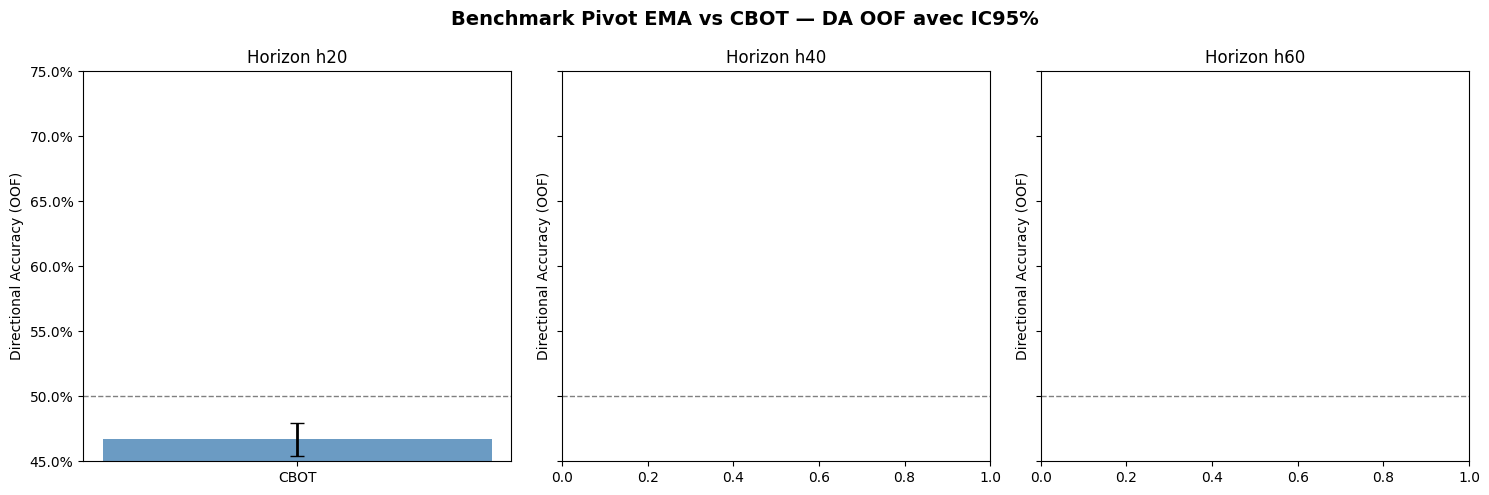

Figure sauvegardée.


In [10]:
# Visualisation comparative
if results and len(results) > 2:
    df_res = pd.DataFrame(results)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    for ax, h in zip(axes, [20, 40, 60]):
        sub = df_res[df_res["horizon"] == h]
        for _, row in sub.iterrows():
            color = "steelblue" if row["target"] == "CBOT" else "tomato"
            ax.bar(row["target"], row["da"], color=color, alpha=0.8, label=row["target"])
            ax.errorbar(
                row["target"], row["da"],
                yerr=[[row["da"] - row["da_ci95_lo"]], [row["da_ci95_hi"] - row["da"]]],
                fmt="none", color="black", capsize=5, linewidth=2,
            )
        ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random (0.5)")
        ax.set_title(f"Horizon h{h}")
        ax.set_ylabel("Directional Accuracy (OOF)")
        ax.set_ylim(0.45, 0.75)
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

    fig.suptitle("Benchmark Pivot EMA vs CBOT — DA OOF avec IC95%", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(project_root / "artefacts" / "benchmark_pivot_ema.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure sauvegardée.")
else:
    print("Données insuffisantes pour la visualisation")

In [11]:
import json

output_dir = project_root / "artefacts" / "benchmark_pivot"
output_dir.mkdir(parents=True, exist_ok=True)

if results:
    df_res = pd.DataFrame(results)
    df_res.to_csv(output_dir / "tableau_benchmark_pivot.csv", index=False)

    cbot_ref = df_res[(df_res["target"] == "CBOT") & (df_res["horizon"] == 20)]["da"].values
    ema_ref  = df_res[(df_res["target"] == "EMA")  & (df_res["horizon"] == 20)]["da"].values

    verdict_data = {
        "generated_at": pd.Timestamp.now().isoformat(),
        "ema_data_real": not ema_is_proxy,
        "da_cbot_h20": float(cbot_ref[0]) if len(cbot_ref) else None,
        "da_ema_h20": float(ema_ref[0]) if len(ema_ref) else None,
        "verdict": verdict_str,
        "note": (
            "EMA data is a CBOT proxy — benchmark EMA non valide. "
            "Télécharger vrais prix Euronext pour verdict final."
            if ema_is_proxy else
            "Benchmark complet avec vrais prix EMA."
        ),
    }
    (output_dir / "pivot_decision.json").write_text(
        json.dumps(verdict_data, indent=2, ensure_ascii=True)
    )
    print("Résultats sauvegardés:", output_dir)
    print(json.dumps(verdict_data, indent=2))

Résultats sauvegardés: /home/cytech/Desktop/Etude Mais/artefacts/benchmark_pivot
{
  "generated_at": "2026-05-19T01:15:43.671315",
  "ema_data_real": false,
  "da_cbot_h20": 0.4667651403249631,
  "da_ema_h20": null,
  "verdict": "indeterminate_no_ema_data",
  "note": "EMA data is a CBOT proxy \u2014 benchmark EMA non valide. T\u00e9l\u00e9charger vrais prix Euronext pour verdict final."
}
